# PCA Analysis of Input-Output Model

Principal Component Analysis on the influence matrix H = A × L to identify key economic sectors.

## 1. Load Libraries

In [1]:
library(openxlsx)
library(ggplot2)
library(igraph)
library(factoextra)
library(FactoMineR)
library(dendextend)
library(tidyverse)
library("corrr")
library(ggcorrplot)

Warning message:
“package ‘openxlsx’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘igraph’ was built under R version 4.3.3”

Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Warning message:
“package ‘dendextend’ was built under R version 4.3.3”

---------------------
Welcome to dendextend version 1.19.0
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/question

## 2. Load Data & Construct Matrices

In [2]:
data <- read.xlsx("dataset/Input_Output_Tables_2019_2021.xlsx", sheet = "2019IOTable")
iot2019 <- data[2:(2 + 15 - 1), 3:(3 + 15 - 1)]
x <- data[2:(2 + 15 - 1), ncol(data)]

A <- read.xlsx("dataset/Input_Output_Tables_2019_2021.xlsx", sheet = "A")
A <- A[2:(2 + 15 - 1), 3:(3 + 15 - 1)]
A <- as.matrix(sapply(A, as.numeric))
n_sectors <- nrow(A)

I_minus_A <- diag(nrow(A)) - A
L <- solve(I_minus_A)

## 3. Rasmussen-Hirschman Linkages

Compute backward (column sums of L) and forward (row sums of L) linkages,
normalized by their means.

In [3]:
calculate_linkages <- function(L_matrix, x_vector = NULL) {
  BL <- colSums(L_matrix)
  BL_normalized <- BL / mean(BL)
  FL <- rowSums(L_matrix)
  FL_normalized <- FL / mean(FL)
  total_linkages <- (BL_normalized + FL_normalized) / 2
  return(data.frame(
    Sector_ID = 1:length(BL),
    BL = BL, BL_normalized = BL_normalized,
    FL = FL, FL_normalized = FL_normalized,
    Total_Linkage = total_linkages
  ))
}

linkages <- calculate_linkages(L)
cat("\nRasmussen-Hirschman Linkages:\n")
print(linkages %>% arrange(desc(Total_Linkage)))


Rasmussen-Hirschman Linkages:
   Sector_ID       BL BL_normalized       FL FL_normalized Total_Linkage
3          3 1.999140     1.3353756 1.808629     1.2081192     1.2717474
2          2 1.363141     0.9105443 2.300775     1.5368609     1.2237026
5          5 1.618468     1.0810966 1.791858     1.1969170     1.1390068
8          8 1.456976     0.9732237 1.834746     1.2255645     1.0993941
7          7 1.538089     1.0274053 1.615614     1.0791898     1.0532976
1          1 1.560235     1.0421984 1.585531     1.0590953     1.0506469
10        10 1.389014     0.9278270 1.596547     1.0664541     0.9971406
4          4 1.440028     0.9619032 1.543702     1.0311547     0.9965290
9          9 1.521379     1.0162437 1.448843     0.9677912     0.9920175
11        11 1.310023     0.8750629 1.469179     0.9813753     0.9282191
12        12 1.533600     1.0244066 1.125035     0.7514953     0.8879510
6          6 1.537185     1.0268015 1.107114     0.7395244     0.8831629
14        14 1.45970

## 4. Construct H Matrix & Perform PCA

H = A × L is the influence matrix. PCA via eigendecomposition of H.

In [4]:
construct_H_matrix <- function(A) {
  I_minus_A <- diag(nrow(A)) - A
  L <- solve(I_minus_A)
  H <- A %*% L
  return(H)
}

H <- construct_H_matrix(A)

In [5]:
perform_pca <- function(H_matrix) {
  eigen_result <- eigen(H_matrix)
  eigenvalues <- eigen_result$values
  eigenvectors <- eigen_result$vectors
  variance_explained <- eigenvalues / sum(eigenvalues)
  cumulative_variance <- cumsum(variance_explained)
  return(list(
    eigenvalues = Re(eigenvalues),
    eigenvectors = Re(eigenvectors),
    variance_explained = Re(variance_explained),
    cumulative_variance = Re(cumulative_variance)
  ))
}

pca_result <- perform_pca(H)

PC1 <- pca_result$eigenvectors[, 1]
PC2 <- pca_result$eigenvectors[, 2]

pca_data <- data.frame(
  Sector_ID = 1:nrow(A),
  PC1 = PC1, PC2 = PC2,
  Eigenvalue_1 = pca_result$eigenvalues[1],
  Eigenvalue_2 = pca_result$eigenvalues[2]
)

## 5. Scree Plot

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”



Variance Explained by Principal Components:
  PC  Variance Cumulative
1  1 28.000325   28.00033
2  2 19.897228   47.89755
3  3 13.666359   61.56391
4  4 11.696211   73.26012
5  5  7.318429   80.57855


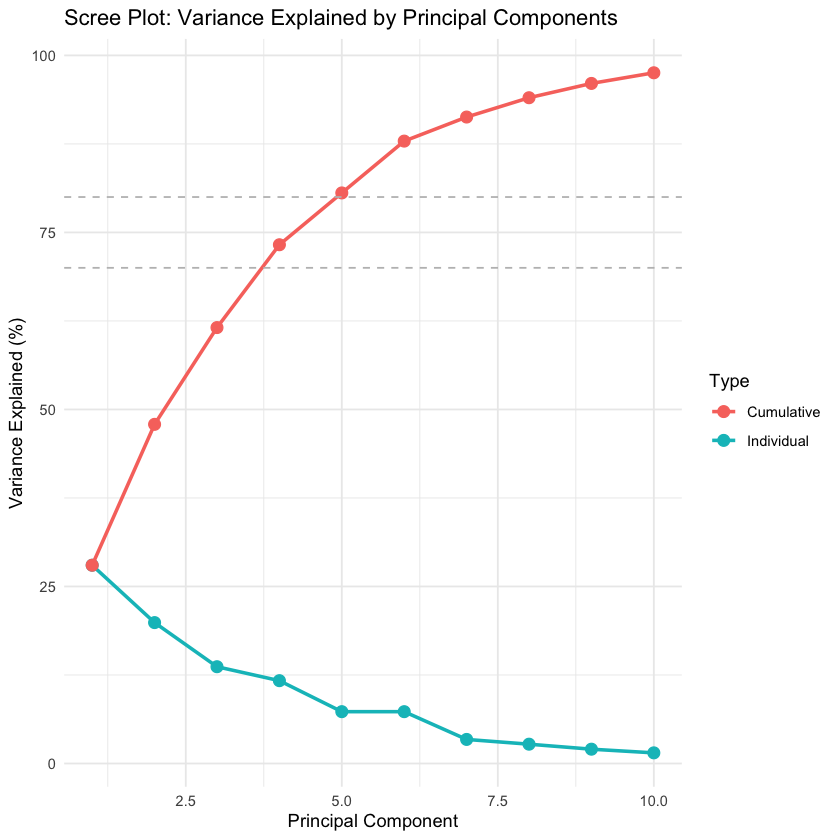

In [6]:
plot_scree <- function(pca_result, sector_names = NULL) {
  n_components <- min(10, length(pca_result$variance_explained))
  scree_data <- data.frame(
    Component = 1:n_components,
    Variance_Explained = pca_result$variance_explained[1:n_components] * 100,
    Cumulative = pca_result$cumulative_variance[1:n_components] * 100
  )
  p <- ggplot(scree_data, aes(x = Component)) +
    geom_line(aes(y = Variance_Explained, color = "Individual"), size = 1) +
    geom_point(aes(y = Variance_Explained, color = "Individual"), size = 3) +
    geom_line(aes(y = Cumulative, color = "Cumulative"), size = 1) +
    geom_point(aes(y = Cumulative, color = "Cumulative"), size = 3) +
    geom_hline(yintercept = 70, linetype = "dashed", color = "gray", size = 0.5) +
    geom_hline(yintercept = 80, linetype = "dashed", color = "gray", size = 0.5) +
    labs(title = "Scree Plot: Variance Explained by Principal Components",
         x = "Principal Component", y = "Variance Explained (%)", color = "Type") +
    theme_minimal() + theme(legend.position = "right")
  print(p)
  return(scree_data)
}

scree_data <- plot_scree(pca_result)

cat("\nVariance Explained by Principal Components:\n")
print(data.frame(
  PC = 1:5,
  Variance = pca_result$variance_explained[1:5] * 100,
  Cumulative = pca_result$cumulative_variance[1:5] * 100
))

## 6. Factor Map

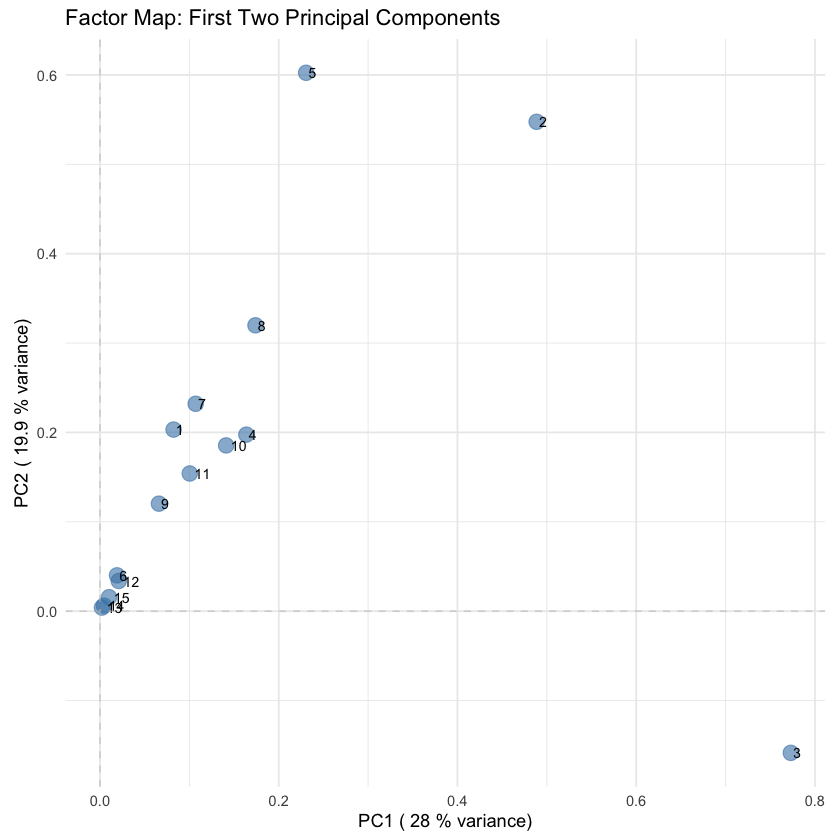

In [7]:
plot_factor_map <- function(pca_data, sector_labels = NULL) {
  if (is.null(sector_labels)) {
    sector_labels <- paste("S", pca_data$Sector_ID, sep = "")
  }
  p <- ggplot(pca_data, aes(x = PC1, y = PC2)) +
    geom_point(size = 4, color = "steelblue", alpha = 0.6) +
    geom_text(aes(label = Sector_ID), size = 3, hjust = -0.3) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "gray", alpha = 0.5) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray", alpha = 0.5) +
    labs(title = "Factor Map: First Two Principal Components",
         x = paste("PC1 (", round(pca_result$variance_explained[1] * 100, 1), "% variance)"),
         y = paste("PC2 (", round(pca_result$variance_explained[2] * 100, 1), "% variance)")) +
    theme_minimal() + coord_equal()
  print(p)
  return(p)
}

factor_map <- plot_factor_map(pca_data)

## 7. K-Means Clustering

Elbow method to determine optimal k, then k-means with k=3.

'data.frame':	15 obs. of  2 variables:
 $ PC1: num  0.0824 0.4886 0.773 0.1638 0.2306 ...
 $ PC2: num  0.203 0.548 -0.159 0.198 0.602 ...


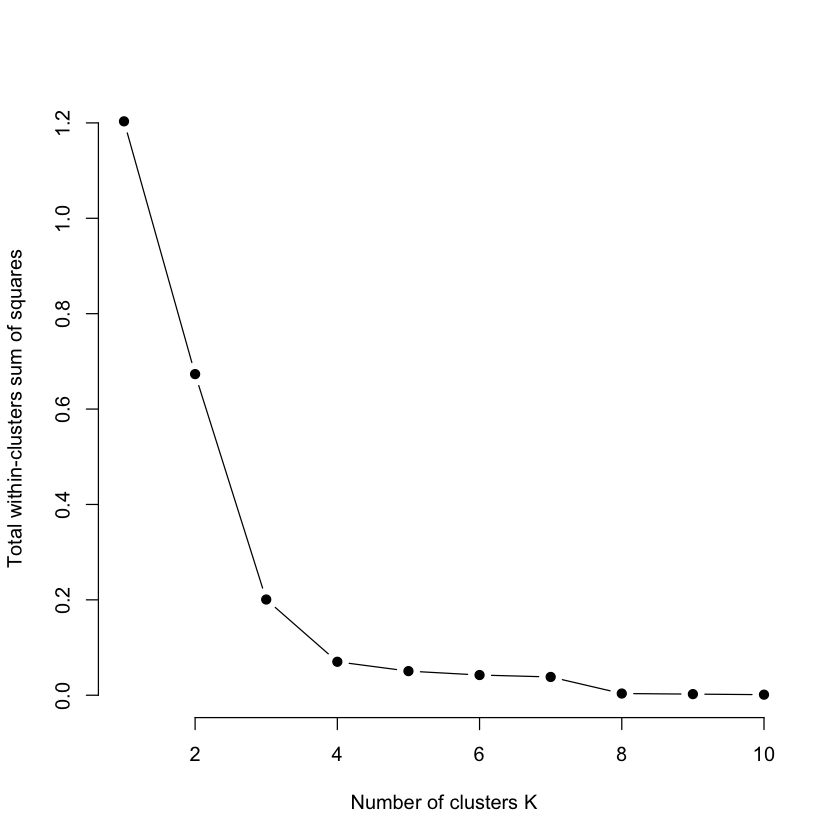

In [8]:
pca_matrix <- pca_data[, 2:3]
str(pca_matrix)

set.seed(100)

wcss <- function(k) {
  kmeans(pca_matrix, k, nstart = 10)$tot.withinss
}

k.values <- 1:10
wcss_k <- sapply(k.values, wcss)
plot(k.values, wcss_k,
  type = "b", pch = 19, frame = FALSE,
  xlab = "Number of clusters K",
  ylab = "Total within-clusters sum of squares"
)

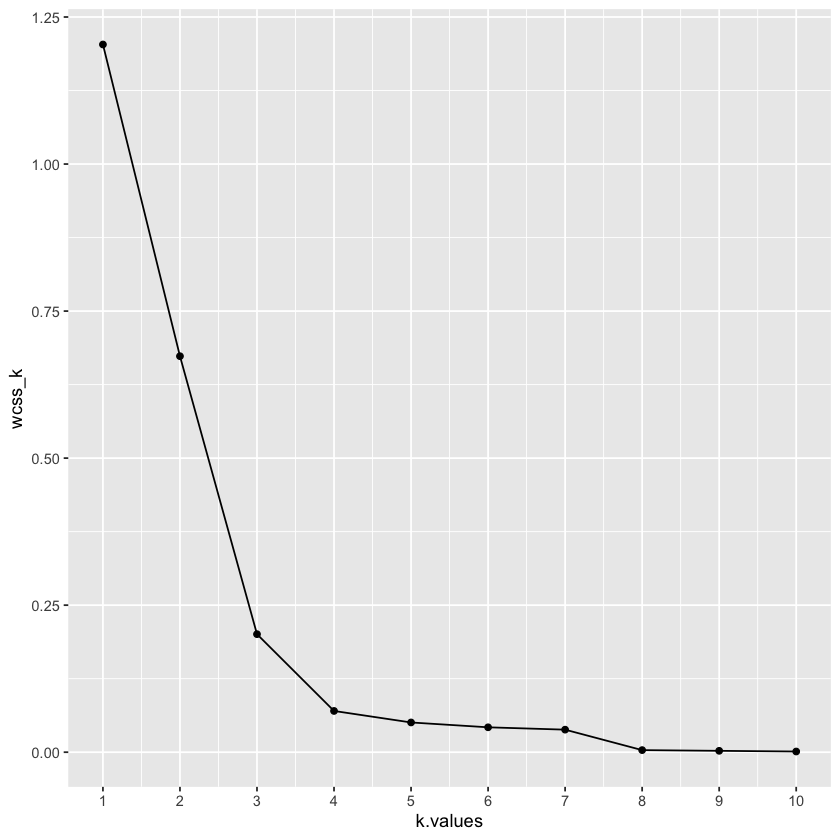

In [9]:
library(ggplot2)
elbow <- data.frame(k.values, wcss_k)
ggplot(elbow, aes(x = k.values, y = wcss_k)) +
  geom_point() +
  geom_line() +
  scale_x_continuous(breaks = seq(1, 30, by = 1))

In [10]:
# Select the elbow point k=3
set.seed(100)
k3 <- kmeans(pca_matrix, centers = 3, nstart = 10)
str(k3)
k3

List of 9
 $ cluster     : int [1:15] 3 2 1 3 2 3 3 3 3 3 ...
 $ centers     : num [1:3, 1:2] 0.773 0.3596 0.0743 -0.1585 0.575 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:3] "1" "2" "3"
  .. ..$ : chr [1:2] "PC1" "PC2"
 $ totss       : num 1.2
 $ withinss    : num [1:3] 0 0.0348 0.1659
 $ tot.withinss: num 0.201
 $ betweenss   : num 1
 $ size        : int [1:3] 1 2 12
 $ iter        : int 2
 $ ifault      : int 0
 - attr(*, "class")= chr "kmeans"


K-means clustering with 3 clusters of sizes 1, 2, 12

Cluster means:
         PC1        PC2
1 0.77297637 -0.1585409
2 0.35960355  0.5749948
3 0.07429264  0.1260238

Clustering vector:
 [1] 3 2 1 3 2 3 3 3 3 3 3 3 3 3 3

Within cluster sum of squares by cluster:
[1] 0.00000000 0.03477242 0.16591576
 (between_SS / total_SS =  83.3 %)

Available components:

[1] "cluster"      "centers"      "totss"        "withinss"     "tot.withinss"
[6] "betweenss"    "size"         "iter"         "ifault"      

## 8. Hierarchical Clustering

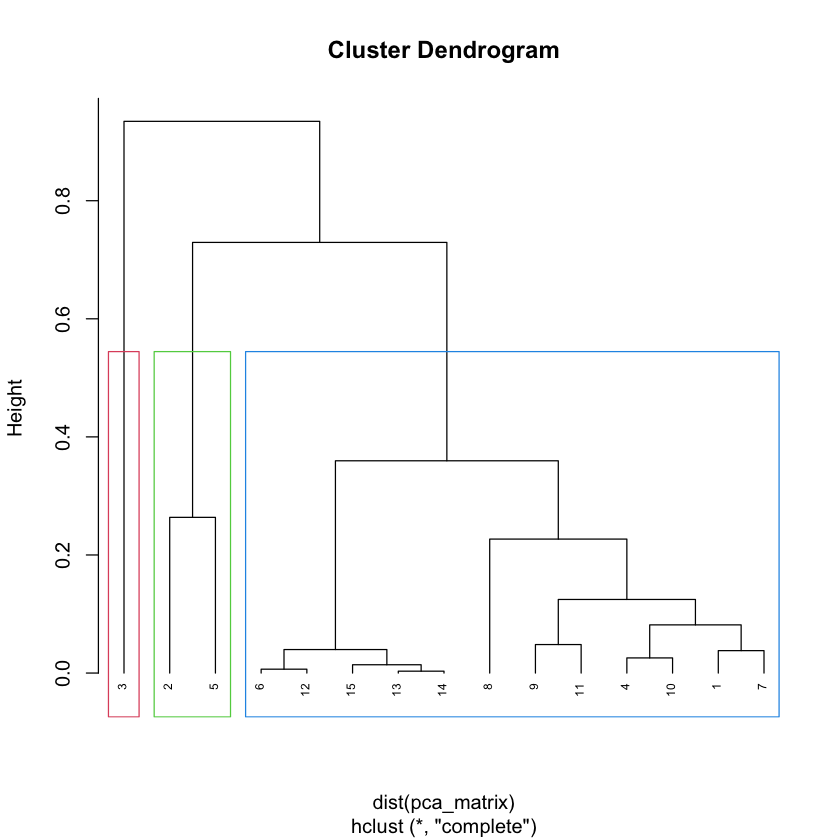

In [11]:
hc1 <- hclust(dist(pca_matrix), method = "complete")
plot(hc1, cex = 0.6, hang = -.1)
rect.hclust(hc1, k = 3, border = 2:8)